## INFORMASI DATA SET (POSTTEST-1)

##### Memanggil library yang akan di pakai di project ini

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

##### Memuat Dataset

In [37]:
df = pd.read_csv("Used Car Dataset.csv")

##### Informasi Deskripsi Dataset

In [38]:
df.describe()

,Unnamed: 0,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
count,1553.000000,1553.000000,1553.000000,1550.000000,1.550000e+03,1.550000e+03,1.549000e+03,1553.000000
mean,776.000000,91.480361,52841.931101,236.927277,1.471857e+10,1.471857e+10,1.423989e+04,166.141494
std,448.456798,2403.424060,40067.800347,585.964295,2.185629e+11,2.185629e+11,9.666241e+04,3478.855090
min,0.000000,4.000000,620.000000,7.810000,5.000000e+00,5.000000e+00,5.000000e+00,1.000000
25%,388.000000,5.000000,30000.000000,16.342500,1.197000e+03,1.197000e+03,4.000000e+02,4.660000
50%,776.000000,5.000000,49134.000000,18.900000,1.462000e+03,1.462000e+03,1.173000e+03,7.140000
75%,1164.000000,5.000000,70000.000000,22.000000,1.995000e+03,1.995000e+03,8.850000e+03,17.000000
max,1552.000000,67000.000000,810000.000000,3996.000000,3.258640e+12,3.258640e+12,1.464800e+06,95000.000000


##### 10 Record Teratas Dataset

In [39]:
df.select_dtypes(include="number").head(10)

,Unnamed: 0,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,0,5,56000,7.81,2996.0,2996.0,333.0,63.75
1,1,5,30615,17.40,999.0,999.0,9863.0,8.99
2,2,5,24000,20.68,1995.0,1995.0,188.0,23.75
3,3,5,18378,16.50,1353.0,1353.0,13808.0,13.56
4,4,5,44900,14.67,1798.0,1798.0,17746.0,24.00
5,5,5,42000,18.70,1199.0,1199.0,887.0,5.45
6,6,5,36739,18.90,1197.0,1197.0,8186.0,5.12
7,7,5,76000,15.80,1591.0,1591.0,1213.0,9.30
8,8,5,68000,13.50,2987.0,2987.0,25479.0,42.00
9,9,5,28783,17.00,1198.0,1198.0,1085.0,8.02


##### Informasi baris dan kolom dataset

In [40]:
print(f"Jumlah record           : {df.shape[0]}")
print(f"Jumlah attribute        : {df.shape[1]}")
print(f"Nama attribute          : {df.columns.tolist()}")
print(f"Jumlah Attribute bertipe angka: {df.select_dtypes(include='number').shape[1]}")
print(f"Jumlah Atribute bertipe object: {df.select_dtypes(include='object').shape[1]}")

Jumlah record           : 1553
Jumlah attribute        : 15
Nama attribute          : ['Unnamed: 0', 'car_name', 'registration_year', 'insurance_validity', 'fuel_type', 'seats', 'kms_driven', 'ownsership', 'transmission', 'manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)', 'price(in lakhs)']
Jumlah Attribute bertipe angka: 8
Jumlah Atribute bertipe object: 7


##### Informasi isi dataset

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1553 entries, 0 to 1552
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1553 non-null   int64  
 1   car_name            1553 non-null   object 
 2   registration_year   1553 non-null   object 
 3   insurance_validity  1553 non-null   object 
 4   fuel_type           1553 non-null   object 
 5   seats               1553 non-null   int64  
 6   kms_driven          1553 non-null   int64  
 7   ownsership          1553 non-null   object 
 8   transmission        1553 non-null   object 
 9   manufacturing_year  1553 non-null   object 
 10  mileage(kmpl)       1550 non-null   float64
 11  engine(cc)          1550 non-null   float64
 12  max_power(bhp)      1550 non-null   float64
 13  torque(Nm)          1549 non-null   float64
 14  price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(3), object(7)
memory usage: 182.1+

##### Korelasi antar kolom numerik

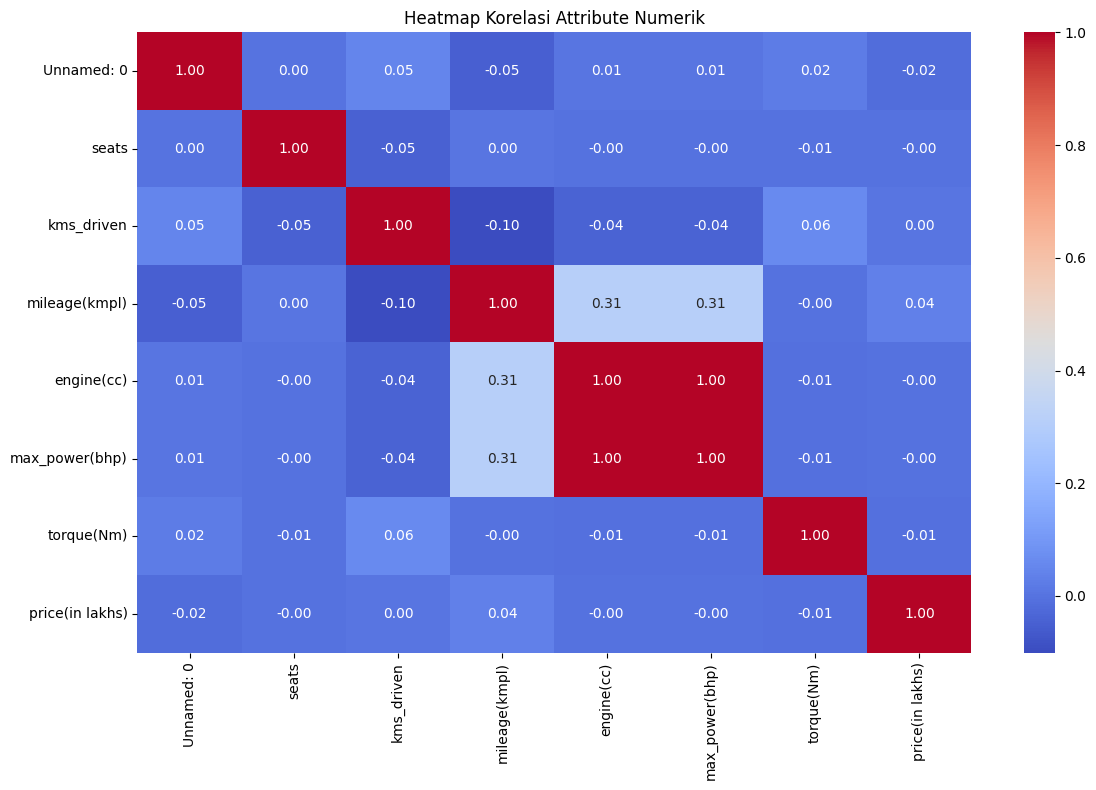

In [42]:
df_numeric = df.select_dtypes(include='number')

korelasi = df_numeric.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    korelasi,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Attribute Numerik')
plt.tight_layout()
plt.show()

## EXPORATORY DATA ANALYSIS (EDA) (POSTTEST-2)

### CLEANING DATA

##### Memuat informasi data yang hilang (missing values)

In [43]:
df.isnull().sum()

Unnamed: 0            0
car_name              0
registration_year     0
insurance_validity    0
fuel_type             0
seats                 0
kms_driven            0
ownsership            0
transmission          0
manufacturing_year    0
mileage(kmpl)         3
engine(cc)            3
max_power(bhp)        3
torque(Nm)            4
price(in lakhs)       0
dtype: int64

##### Menghapus baris dataset yang kehilangan value

In [44]:
df = df.dropna()

##### menghapus kolom "Unnamed:0" dan baris yang isi datanya sama (duplicates)

In [45]:
df = df.drop(columns="Unnamed: 0")
df = df.drop_duplicates()
df = df.dropna()

### PENANGANAN OUTLIERS

##### Fungsi yang memuat grafik boxplot untuk meanmpilakan dan menghitung data yang menyimpang (outlier)

In [46]:
kolom_num = ["seats", "kms_driven", "mileage(kmpl)", "engine(cc)", "price(in lakhs)"]
 
 
def boxplot_semua(data, kolom, judul):
    n = len(kolom)
    baris = (n + 2) // 3
    fig, axes = plt.subplots(baris, 3, figsize=(12, 4 * baris))
    axes = axes.flatten()
    for ax, k in zip(axes, kolom):
        sns.boxplot(y=data[k], ax=ax)
        ax.set_title(k)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(judul)
    plt.tight_layout()
    plt.show()

def hitung_outlier(data, kolom):
    for k in kolom:
        Q1, Q3 = data[k].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        n = ((data[k] < Q1 - 1.5 * IQR) | (data[k] > Q3 + 1.5 * IQR)).sum()
        print(f"{k}: {n} outlier")


##### Mendeteksi Outlier

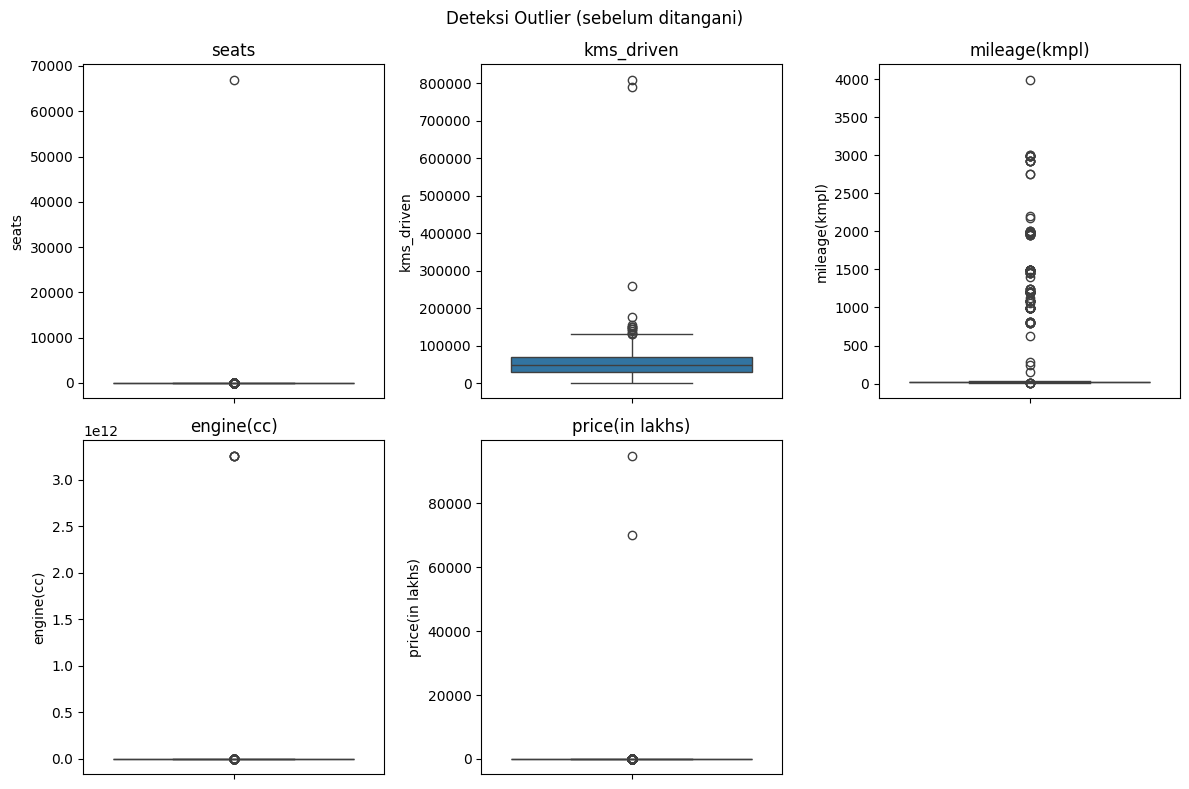

seats: 137 outlier
kms_driven: 14 outlier
mileage(kmpl): 165 outlier
engine(cc): 94 outlier
price(in lakhs): 146 outlier


In [47]:
boxplot_semua(df, kolom_num, "Deteksi Outlier (sebelum ditangani)")
hitung_outlier(df, kolom_num)

##### Memisahkan Outliers error dengan Outliers Wajar

In [48]:
print("\nseats > 10        :", (df["seats"] > 10).sum())
print("mileage > 50      :", (df["mileage(kmpl)"] > 50).sum())
print("engine di luar 500-7000 cc:", (~df["engine(cc)"].between(500, 7000)).sum())
print("kms_driven > 500000:", (df["kms_driven"] > 500000).sum())
print("price > 500 lakh  :", (df["price(in lakhs)"] > 500).sum())
print("max_power sama persis dengan engine:", (df["engine(cc)"] == df["max_power(bhp)"]).mean())
print("torque di luar 40-1000 Nm:", (~df["torque(Nm)"].between(40, 1000)).sum())


seats > 10        : 1
mileage > 50      : 159
engine di luar 500-7000 cc: 103
kms_driven > 500000: 2
price > 500 lakh  : 2
max_power sama persis dengan engine: 1.0
torque di luar 40-1000 Nm: 633


##### Menanangi Outliers

Harga crore diperbaiki: 17

Baris dihapus (nilai mustahil): 161
Ukuran akhir: (969, 12)
seats: 115 outlier
kms_driven: 13 outlier
mileage(kmpl): 20 outlier
engine(cc): 12 outlier
price(in lakhs): 133 outlier


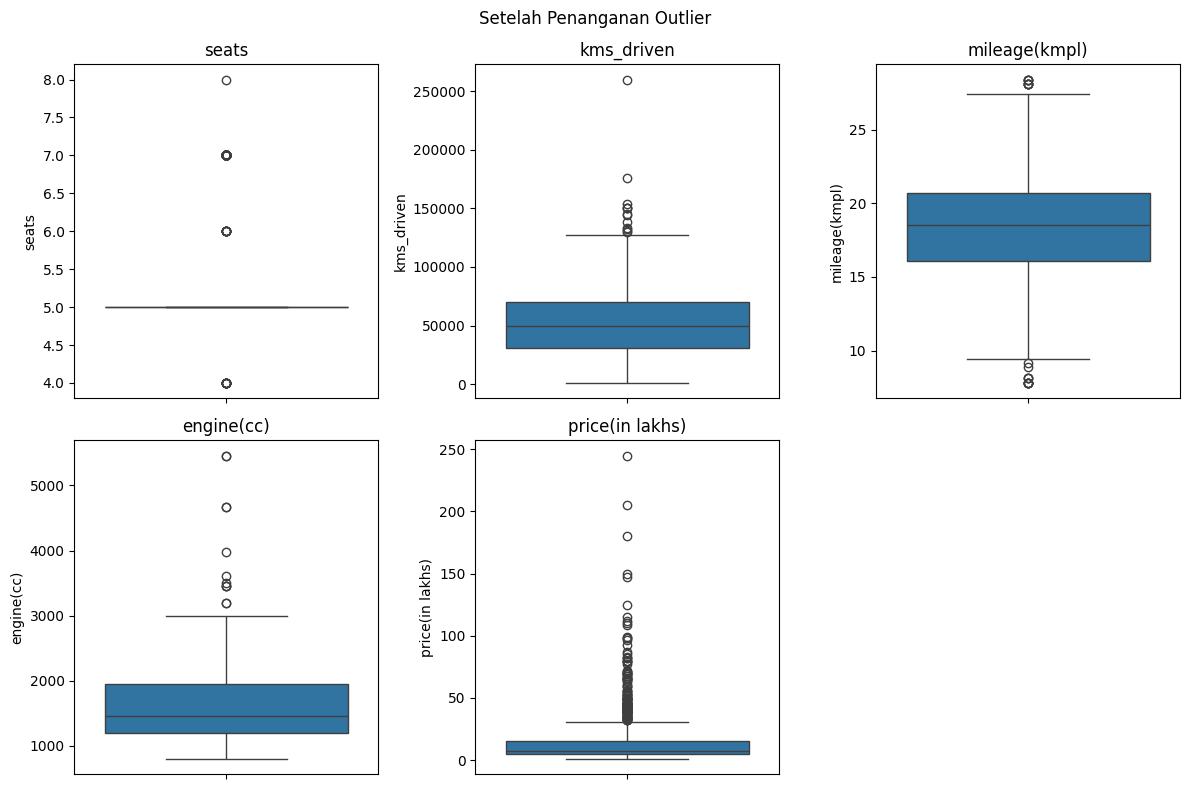

In [49]:
# a) Menghapus kolom.
#    - max_power(bhp) hampir 100% sama dengan engine(cc) -> salah salin.
#    - torque(Nm) mayoritas berisi angka mustahil (ribuan) -> tidak bisa dipakai.
df = df.drop(columns=["max_power(bhp)", "torque(Nm)"])
 
# b) Memperbaiki satuan
#    Harga > 500 lakh (mis. 95000) sebenarnya dalam rupiah India, bukan lakh.
#    1 lakh = 100.000, jadi dibagi 100000.
df.loc[df["price(in lakhs)"] > 500, "price(in lakhs)"] /= 100000

# b2) Harga mobil mewah yang tercatat dalam crore -> ubah ke lakh
#     1 crore = 100 lakh. Mobil mewah dengan harga < 3 lakh tidak masuk akal.
merek = df["car_name"].str.split().str[1]
mewah = ["Mercedes-Benz", "BMW", "Audi", "Porsche", "Land", "Jaguar", "Volvo", "Lexus", "Mini", "Maserati", "Bentley"]
crore = merek.isin(mewah) & (df["price(in lakhs)"] < 3)
print("Harga crore diperbaiki:", crore.sum())
df.loc[crore, "price(in lakhs)"] *= 100
 
# c) Filterasi data yang masuk akal
#    mileage berisi angka cc, engine berisi angka acak, seats = 67000, dst.
valid = (
    (df["seats"] <= 10)
    & (df["mileage(kmpl)"] <= 50)
    & (df["engine(cc)"].between(500, 7000))
    & (df["kms_driven"] <= 500000)
)
print("\nBaris dihapus (nilai mustahil):", (~valid).sum())
df = df[valid].reset_index(drop=True)
 
# Hasil akhir
print("Ukuran akhir:", df.shape)
hitung_outlier(df, kolom_num)
boxplot_semua(df, kolom_num, "Setelah Penanganan Outlier")

### NORMALISASI DAN STANDARISASI

##### Standarisasi menggunakan Z-Score

In [50]:
from sklearn.preprocessing import StandardScaler

kolom_scale = ["kms_driven", "mileage(kmpl)", "engine(cc)"]

df_std = df.copy()
df_std[kolom_scale] = StandardScaler().fit_transform(df[kolom_scale])

print(df_std[kolom_scale].describe().loc[['mean', 'std']])

        kms_driven  mileage(kmpl)    engine(cc)
mean -9.532565e-17  -1.466548e-17 -1.466548e-16
std   1.000516e+00   1.000516e+00  1.000516e+00


### ENCODING KOLOM KATEGORIAL

##### Ordinal koloom "ownership"

In [51]:
urutan = {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3,
          'Fourth Owner': 4, 'Fifth Owner': 5}
df['ownsership'] = df['ownsership'].map(urutan)

##### One-Hot Encoding kolom kategorikal

In [52]:
# Menggabungkan value yang sama
df['insurance_validity'] = df['insurance_validity'].replace('Third Party insurance', 'Third Party')

# One-Hot: fuel_type, transmission, insurance_validity
df = pd.get_dummies(df, columns=['fuel_type', 'transmission', 'insurance_validity'],
                    drop_first=True, dtype=int)

##### Mengubah format tahun

In [53]:
th = pd.to_numeric(df['registration_year'].str.extract(r'(\d+)$')[0])
df['registration_year'] = th.where(th > 100, th + 2000).astype(int)

df['manufacturing_year'] = pd.to_numeric(df['manufacturing_year'])

### FUTURE ENGINERING

##### Menambahkan kolom usia mobil

In [54]:
TAHUN_ACUAN = 2026
df['usia_mobil'] = TAHUN_ACUAN - df['manufacturing_year']

##### Menambahkan kolom brand

In [55]:
df['brand'] = df['car_name'].str.split().str[1]
df['brand'] = df['brand'].replace('Land', 'Land Rover')  

jumlah = df['brand'].value_counts()
langka = jumlah[jumlah < 10].index
df['brand'] = df['brand'].replace(langka, 'Other')

##### Menambahkan kolom kilometer/tahun

In [56]:
df['km_per_tahun'] = df['kms_driven'] / (df['usia_mobil'] + 1)

##### Mengapus kolomo yang tidak berguna

In [57]:
df = df.drop(columns=['registration_year', 'manufacturing_year', 'car_name'])

##### One Hot Encoding kolom brand

In [58]:
df = pd.get_dummies(df, columns=['brand'], drop_first=True, dtype=int)

##### Memuat kembali struktur data terbaru

In [59]:
df.head()

,seats,kms_driven,ownsership,mileage(kmpl),engine(cc),price(in lakhs),fuel_type_Diesel,fuel_type_Petrol,transmission_Manual,insurance_validity_Not Available,...,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Nissan,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,5,56000,1,7.81,2996.0,63.75,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,5,30615,1,17.40,999.0,8.99,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,5,24000,1,20.68,1995.0,23.75,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,18378,1,16.50,1353.0,13.56,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,44900,1,14.67,1798.0,24.00,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


## MODELING (POSTTEST-3)

##### Memeriksa kembali informasi dataset

In [61]:
cek = pd.DataFrame({
    "Pemeriksaan": ["Jumlah baris", "Jumlah kolom", "Missing value", "Baris duplikat",
                    "Kolom non-numerik", "Nilai tak hingga (inf)", "Kolom konstan"],
    "Hasil": [df.shape[0], df.shape[1], int(df.isnull().sum().sum()), int(df.duplicated().sum()),
              int(df.select_dtypes(exclude="number").shape[1]),
              int(np.isinf(df.select_dtypes("number")).sum().sum()),
              int((df.nunique() <= 1).sum())]
})
print(cek.to_string(index=False))

y = df["price(in lakhs)"]
print(f"\nSkewness target  : {y.skew():.2f}")
print(f"Rasio baris/fitur: {df.shape[0] / (df.shape[1] - 1):.1f}")

           Pemeriksaan  Hasil
          Jumlah baris    969
          Jumlah kolom     31
         Missing value      0
        Baris duplikat      1
     Kolom non-numerik      0
Nilai tak hingga (inf)      0
         Kolom konstan      0

Skewness target  : 4.12
Rasio baris/fitur: 32.3


##### menginisiasikan properti model

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, r2_score,mean_absolute_percentage_error

##### Melatih model 1 (Linear Regression) dan model 2 (Random Forest)

In [ ]:
# Pisahkan fitur dan target
X = df.drop(columns="price(in lakhs)")
y = df["price(in lakhs)"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data training : {X_train.shape[0]} baris")
print(f"Data testing  : {X_test.shape[0]} baris")

# Model 1: Linear Regression (scaling di dalam pipeline, target di-log)
model_lr = TransformedTargetRegressor(
    regressor=Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    func=np.log1p, inverse_func=np.expm1,
)

# Model 2: Random Forest
model_rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

# Pelatihan
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

Data training : 775 baris
Data testing  : 194 baris

Kedua model selesai dilatih.


##### Memprediksi hasil training pada data testing

In [76]:
# Prediksi pada data testing (disimpan karena dipakai lagi untuk grafik di soal 5)
pred = {
    "Linear Regression": model_lr.predict(X_test),
    "Random Forest": model_rf.predict(X_test),
}

hasil = pd.DataFrame({
    nama: {
        "MAE (lakh)": mean_absolute_error(y_test, p),
        "MAPE (%)": mean_absolute_percentage_error(y_test, p) * 100,
        "R²": r2_score(y_test, p),
    }
    for nama, p in pred.items()
}).T.round(3)

print(hasil)

                   MAE (lakh)  MAPE (%)     R²
Linear Regression       4.828    22.726  0.675
Random Forest           5.437    24.011  0.585


##### Visualisasi Hasil model

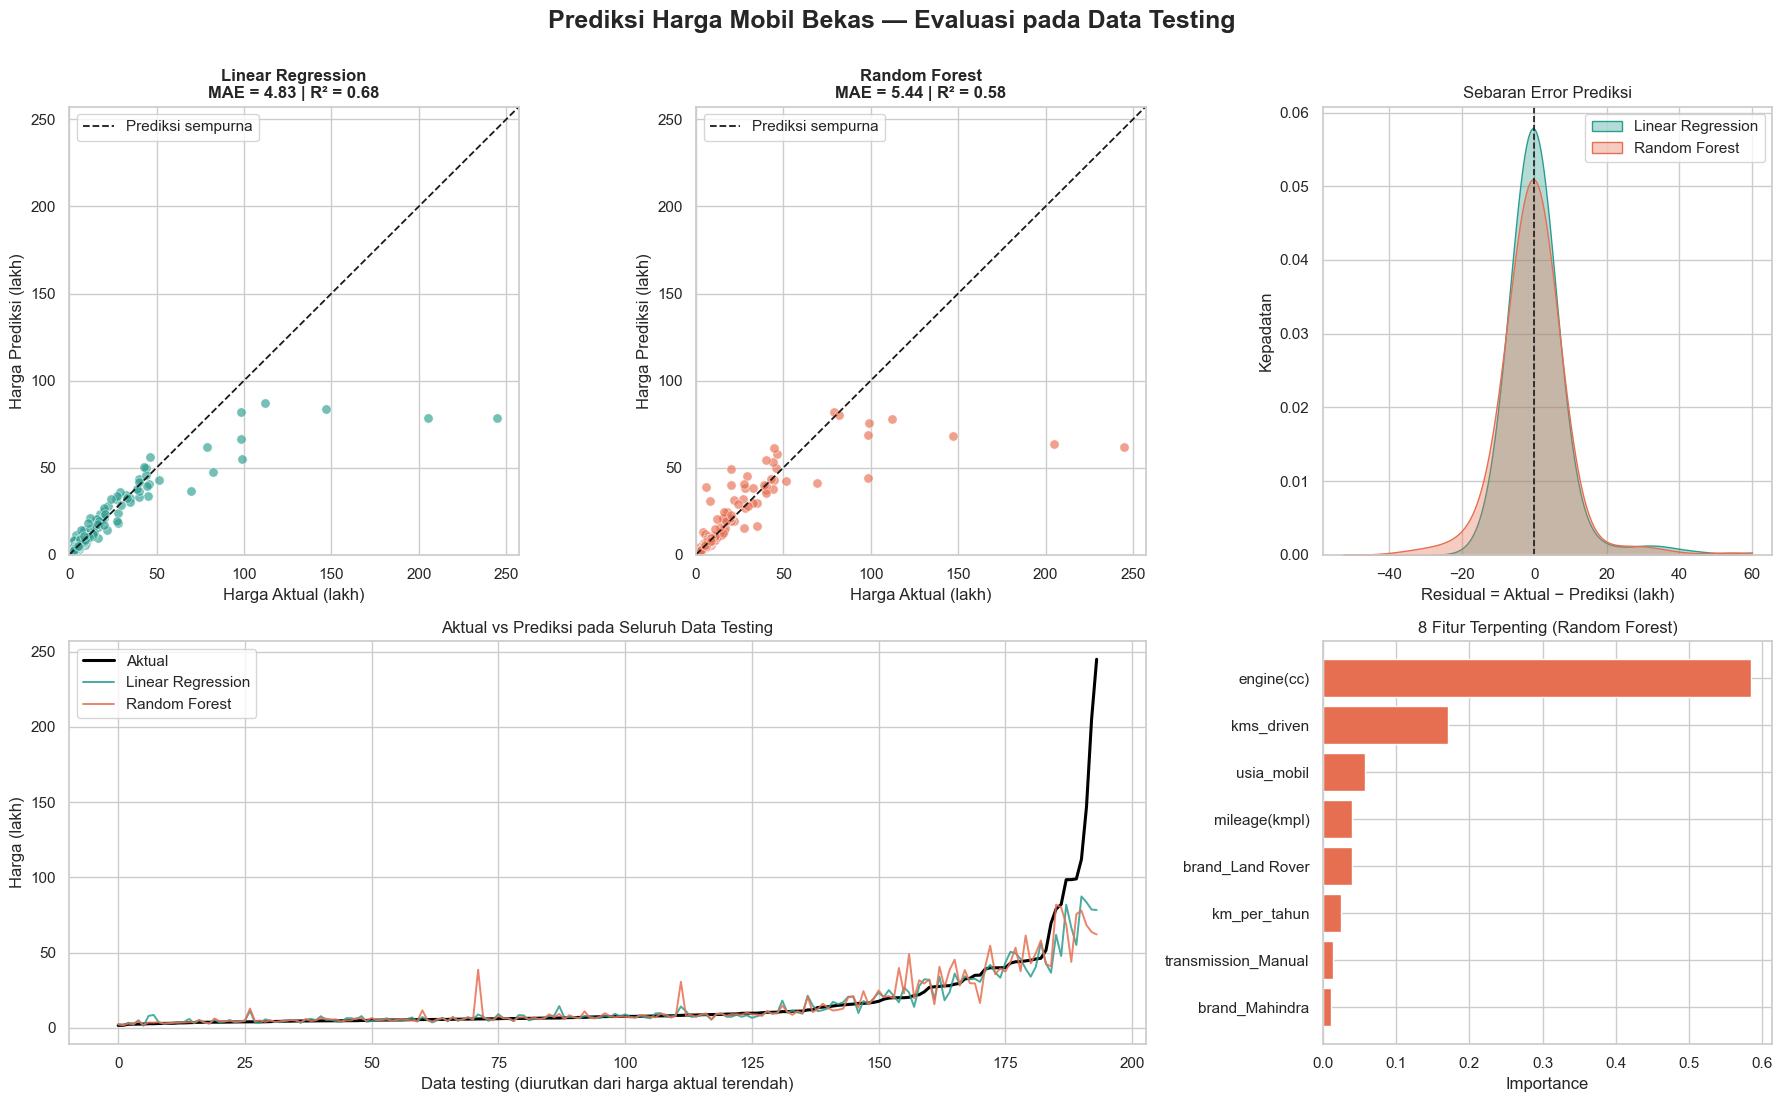

In [66]:
sns.set_theme(style="whitegrid", context="notebook")
warna = {"Linear Regression": "#2A9D8F", "Random Forest": "#E76F51"}

fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.9])
lim = max(y_test.max(), max(p.max() for p in pred.values())) * 1.05

# Baris 1: scatter aktual vs prediksi per model
for i, (nama, p) in enumerate(pred.items()):
    ax = fig.add_subplot(gs[0, i])
    ax.scatter(y_test, p, c=warna[nama], s=45, alpha=.65, edgecolor="white", linewidth=.5)
    ax.plot([0, lim], [0, lim], "k--", lw=1.3, label="Prediksi sempurna")
    ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="Harga Aktual (lakh)", ylabel="Harga Prediksi (lakh)")
    ax.set_title(f"{nama}\nMAE = {hasil.loc[nama, 'MAE (lakh)']:.2f} | R² = {hasil.loc[nama, 'R²']:.2f}",
                 fontweight="bold")
    ax.legend(loc="upper left")

# Baris 1 kolom 3: sebaran residual
ax = fig.add_subplot(gs[0, 2])
for nama, p in pred.items():
    sns.kdeplot(y_test - p, ax=ax, fill=True, alpha=.35, color=warna[nama], label=nama, clip=(-60, 60))
ax.axvline(0, color="k", ls="--", lw=1.2)
ax.set(xlabel="Residual = Aktual − Prediksi (lakh)", ylabel="Kepadatan", title="Sebaran Error Prediksi")
ax.legend()

# Baris 2: garis aktual vs prediksi, diurutkan berdasarkan harga aktual
ax = fig.add_subplot(gs[1, :2])
urut = y_test.sort_values().index
pos = [y_test.index.get_loc(k) for k in urut]
xs = np.arange(len(urut))
ax.plot(xs, y_test.loc[urut].values, color="black", lw=2.2, label="Aktual")
for nama, p in pred.items():
    ax.plot(xs, p[pos], color=warna[nama], lw=1.4, alpha=.85, label=nama)
ax.set(xlabel="Data testing (diurutkan dari harga aktual terendah)", ylabel="Harga (lakh)",
       title="Aktual vs Prediksi pada Seluruh Data Testing")
ax.legend()

# Baris 2 kolom 3: fitur terpenting Random Forest
ax = fig.add_subplot(gs[1, 2])
imp = pd.Series(model_rf.feature_importances_, index=X.columns).nlargest(8).sort_values()
ax.barh(imp.index, imp.values, color="#E76F51")
ax.set(title="8 Fitur Terpenting (Random Forest)", xlabel="Importance")

fig.suptitle("Prediksi Harga Mobil Bekas — Evaluasi pada Data Testing", fontsize=18, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()